# Sensitivity of Gulf Stream eddy results
The 1 cm minimum amplitude preserved the main CHL directions and radial contrast, but it changed target membership and the anticyclone group heatmaps enough that the production analysis was left at 0.8 cm.

- Target cyclones changed from 25 to 24; target anticyclones changed from 42 to 38. The baseline had 783 target composites and the 1 cm run had 765.
- Late-age CHL change remained negative for cyclones and positive for anticyclones, with both 95% bootstrap intervals excluding zero. The estimates changed from −0.074 to −0.084 mg/m³ and from +0.082 to +0.123 mg/m³, respectively.
- The CHL core remained higher than the outer rings in cyclones and lower in anticyclones. Some phytoplankton-group change intervals switched between including and excluding zero.
- A new 1 cm target anticyclone, track 309, drove much of the larger anticyclone increase and the late-age diatom hotspot. Its influence is shown explicitly below.

These findings describe the executed parameter settings. Rerun the cells after editing parameters; the tables and figures update, while this written summary remains a record of the original experiment.

## Experiment and parameters
The experiment used all 1,010 daily SSH maps from March 28, 2023, through December 31, 2025. PET detection and tracking were rerun in scratch. The 4 mm contour interval, 500 km filter, 55% shape-error limit, secondary-extremum threshold, and trajectory smoothing stayed fixed. The minimum-amplitude argument was changed independently through `nb_step_min = amplitude_m / contour_step_m`.

Each alternative changed one setting from the 0.8 cm, five-gap-day, 30-position, 150 km baseline. Track duration included virtual positions. Endpoint classes used the unchanged daily Gulf Stream axis. Target selection and sampling were recalculated from each scenario's own tracks.

Run with the repository's Python environment. A matching scratch cache avoids repeating the expensive stages; deleting the cache or changing parameters, notebook code, source code, or input-file metadata triggers a fresh run. Outputs in this notebook remain visible if the operating system later removes scratch. No production data or configuration is written.

In [1]:
from pathlib import Path
from tempfile import mkdtemp
from time import perf_counter
from typing import cast
import datetime as dt
import hashlib
import json
import logging
import warnings
import sys

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from IPython.display import display
from joblib import Parallel, delayed

PROJECT_ROOT = Path('/Users/jerry/school/research/eddy-tracking')
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
from eddy_tracking.config import load_config, resolve_data_dir
from eddy_tracking.packages.py_eddy_tracker.dataset.grid import RegularGridDataset
from eddy_tracking.packages.py_eddy_tracker.observations.observation import EddiesObservations
from eddy_tracking.packages.py_eddy_tracker.observations.tracking import TrackEddiesObservations
from eddy_tracking.pipeline.eddy_track import track
from eddy_tracking.preprocess.swot import index_swot_files_by_date
from eddy_tracking.preprocess.streamline import compute_signed_distance_km
from eddy_tracking.preprocess.tracks import mask_pixels_inside_contour

EXPERIMENT = 'gulf_stream_20240305_20260531'
CACHE_DIRECTORY = Path('/tmp/codex-eddy-sensitivity.7q0BVW')
N_WORKERS = 4
N_AGE_BINS = 5
N_RADIAL_BINS = 10
N_BOOTSTRAP = 2000
RANDOM_SEED = 2026
HEATMAP_FIELDS = ('CHL', 'DIATO', 'PROKAR')
PARAMETERS = {
    'Baseline 0.8 cm': (0.8, 5, 30, 150, False),
    'Amplitude 1 cm': (1.0, 5, 30, 150, False),
    'Amplitude 2 cm': (2.0, 5, 30, 150, False),
    'Gap 3 days': (0.8, 3, 30, 150, False),
    'Minimum 60 days': (0.8, 5, 60, 150, False),
    'Proximity 100 km': (0.8, 5, 30, 100, False),
    'Proximity 200 km': (0.8, 5, 30, 200, False),
    'Exclude record edges': (0.8, 5, 30, 150, True),
}
cfg = load_config(EXPERIMENT)
DATA_DIR = PROJECT_ROOT / 'data' / EXPERIMENT
polarity_names = ('cyclone', 'anticyclone')
identity_columns = ['polarity', 'track_id']
groups = ['DIATO', 'DINO', 'GREEN', 'HAPTO', 'PROCHLO', 'PROKAR', 'MICRO', 'NANO', 'PICO']
fields_to_use = ['CHL', *groups]
AMPLITUDE_CM = tuple(sorted({values[0] for values in PARAMETERS.values()}))
TRACKING_RUNS = sorted({values[:3] for values in PARAMETERS.values()})
SCENARIOS = {
    name: (f'amplitude_{amplitude:g}_gap_{gap}_days_{days}', proximity, exclude_edges)
    for name, (amplitude, gap, days, proximity, exclude_edges) in PARAMETERS.items()
}
swot_files = index_swot_files_by_date(resolve_data_dir(cfg, 'swot_dir'))
parameter_table = pd.DataFrame.from_dict(PARAMETERS, orient='index', columns=pd.Index(['amplitude_cm', 'gap_days', 'minimum_positions', 'near_axis_km', 'exclude_record_edges']))
display(parameter_table)
plt.rcParams.update({'font.size': 9, 'axes.titlesize': 10, 'axes.labelsize': 9, 'legend.fontsize': 8, 'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False})

,amplitude_cm,gap_days,minimum_positions,near_axis_km,exclude_record_edges
Baseline 0.8 cm,0.8,5,30,150,False
Amplitude 1 cm,1.0,5,30,150,False
Amplitude 2 cm,2.0,5,30,150,False
Gap 3 days,0.8,3,30,150,False
Minimum 60 days,0.8,5,60,150,False
Proximity 100 km,0.8,5,30,100,False
Proximity 200 km,0.8,5,30,200,False
Exclude record edges,0.8,5,30,150,True


In [2]:
notebook_path = PROJECT_ROOT / 'research_paper/sensitivity.ipynb'
notebook_source = json.loads(notebook_path.read_text())
code_digest = hashlib.sha256('\n'.join(''.join(cell['source']) for cell in notebook_source['cells'] if cell['cell_type'] == 'code').encode()).hexdigest()
source_paths = sorted((PROJECT_ROOT / 'src/eddy_tracking').rglob('*.py'))
source_digest = hashlib.sha256(b''.join(str(path.relative_to(PROJECT_ROOT)).encode() + path.read_bytes() for path in source_paths)).hexdigest()
input_paths = sorted([*swot_files.values(), *resolve_data_dir(cfg, 'plankton_dir').glob('plankton_*.nc'), *(DATA_DIR / 'silver/eddy_id').rglob('*.nc'), DATA_DIR / 'silver/gulf_stream/streamline.parquet', DATA_DIR / 'silver/gulf_stream/eddy_movement.parquet', DATA_DIR / 'gold/eddy_plankton_table.parquet'])
inventory = [(str(path), path.stat().st_size, path.stat().st_mtime_ns) for path in input_paths]
signature = {'notebook_code_sha256': code_digest, 'source_sha256': source_digest, 'input_inventory_sha256': hashlib.sha256(json.dumps(inventory).encode()).hexdigest(), 'config': cfg, 'parameters': {name: list(values) for name, values in PARAMETERS.items()}, 'age_bins': N_AGE_BINS, 'radial_bins': N_RADIAL_BINS, 'bootstrap_draws': N_BOOTSTRAP, 'random_seed': RANDOM_SEED}
SCRATCH = CACHE_DIRECTORY
manifest_path = SCRATCH / 'completed.json'
cached = manifest_path.exists() and json.loads(manifest_path.read_text()) == signature
if not cached:
    SCRATCH = Path(mkdtemp(prefix='codex-eddy-sensitivity-', dir='/tmp'))
    (SCRATCH / 'provenance.json').write_text(json.dumps(signature, indent=2))
print(f'Scratch: {SCRATCH}')
print(f'Matching completed cache: {cached}')
print(f'SSH maps: {len(swot_files)}; first: {min(swot_files)}; last: {max(swot_files)}')

Scratch: /tmp/codex-eddy-sensitivity.7q0BVW
Matching completed cache: True
SSH maps: 1010; first: 2023-03-28; last: 2025-12-31


## Detection and tracking
The baseline regeneration must match every stored daily detection after NetCDF encoding and decoding. Amplitudes in saved files are quantized, so filtering the saved amplitude column is not an exact replacement for rerunning PET with a new threshold.

The functions below use the same identification and tracking code as the pipeline. All new detection and track files are written under `SCRATCH`.

In [3]:
def identify_day(day: dt.date, input_path: Path) -> list[dict]:
    logging.getLogger('pet').setLevel(logging.ERROR)
    warnings.filterwarnings('ignore', message="Warning: 'partition' will ignore")
    with xr.open_dataset(input_path) as dataset:
        lon = dataset['longitude'].to_numpy()
        lat = dataset['latitude'].to_numpy()
    region = cfg['base']['region']
    grid = RegularGridDataset(
        input_path, 'longitude', 'latitude', indexs={
            'time': 0,
            'longitude': slice(np.searchsorted(lon, region['lon_range'][0], 'left'), np.searchsorted(lon, region['lon_range'][1], 'right')),
            'latitude': slice(np.searchsorted(lat, region['lat_range'][0], 'left'), np.searchsorted(lat, region['lat_range'][1], 'right')),
        },
    )
    grid.bessel_high_filter('adt', cfg['eddy_id']['bessel_high_filter_wavelength'])
    rows = []
    for amplitude_cm in AMPLITUDE_CM:
        observations = grid.eddy_identification(
            'adt', 'ugos', 'vgos', dt.datetime.combine(day, dt.time()),
            step=cfg['eddy_id']['step'], shape_error=cfg['eddy_id']['shape_error'],
            nb_step_min=(amplitude_cm / 100) / cfg['eddy_id']['step'],
        )
        for polarity, found in zip(('anticyclone', 'cyclone'), observations):
            name = 'Anticyclonic' if polarity == 'anticyclone' else 'Cyclonic'
            output_dir = SCRATCH / f'amplitude_{amplitude_cm:g}' / 'eddy_id' / polarity
            output_dir.mkdir(parents=True, exist_ok=True)
            output_path = output_dir / f'{name}_{day}.nc'
            found.write_file(filename=str(output_path))
            saved = EddiesObservations.load_file(str(output_path))
            baseline_equal = None
            if amplitude_cm == 0.8:
                existing = EddiesObservations.load_file(str(DATA_DIR / 'silver/eddy_id' / polarity / output_path.name))
                baseline_equal = len(existing) == len(saved) and all(
                    np.array_equal(existing[field], saved[field], equal_nan=True)
                    for field in cast(tuple[str, ...], existing.observations.dtype.names)
                )
            rows.append({'date': str(day), 'polarity': polarity, 'amplitude_cm': amplitude_cm, 'detections': len(found), 'baseline_equal': baseline_equal})
    return rows

def run_detection() -> pd.DataFrame:
    started = perf_counter()
    rows = []
    items = sorted(swot_files.items())
    for first in range(0, len(items), 100):
        results = cast(list[list[dict]], Parallel(n_jobs=N_WORKERS)(delayed(identify_day)(day, path) for day, path in items[first:first + 100]))
        rows.extend(row for result in results for row in result)
        print(f'Identified {min(first + 100, len(items))}/{len(items)} days in {perf_counter() - started:.0f} s', flush=True)
    summary = pd.DataFrame(rows)
    summary.to_parquet(SCRATCH / 'detection_summary.parquet', index=False)
    baseline = summary.loc[summary['amplitude_cm'].eq(0.8)]
    assert baseline['baseline_equal'].all(), 'Regenerated baseline differs from the current daily detections'
    return summary

def run_tracking(amplitude_cm: float, virtual: int, min_track_days: int) -> str:
    label = f'amplitude_{amplitude_cm:g}_gap_{virtual}_days_{min_track_days}'
    for polarity in polarity_names:
        output_dir = SCRATCH / label / 'eddy_track' / polarity
        output_dir.mkdir(parents=True, exist_ok=True)
        track(
            SCRATCH / f'amplitude_{amplitude_cm:g}' / 'eddy_id' / polarity, output_dir,
            virtual=virtual, min_track_days=min_track_days,
            median_half_window=cfg['eddy_track']['position_filter']['median_half_window'],
            loess_half_window=cfg['eddy_track']['position_filter']['loess_half_window'],
        )
    return label

def load_observations(label: str) -> pd.DataFrame:
    frames = []
    for polarity in polarity_names:
        tracked = TrackEddiesObservations.load_file(str(SCRATCH / label / 'eddy_track' / polarity / f'{polarity}_tracks.zarr'))
        keep = ~tracked.virtual.astype(bool)
        frames.append(pd.DataFrame({
            'polarity': polarity, 'track_id': tracked.track[keep].astype(int),
            'date': pd.to_datetime(tracked.time[keep], unit='D', origin='1950-01-01'),
            'center_lon': (tracked.longitude[keep] + 180) % 360 - 180,
            'center_lat': tracked.latitude[keep], 'amplitude_cm': tracked.amplitude[keep] * 100,
            'radius_km': tracked.radius_s[keep] / 1000,
            'contour_lon': list((tracked.contour_lon_s[keep] + 180) % 360 - 180),
            'contour_lat': list(tracked.contour_lat_s[keep]),
        }))
    result = pd.concat(frames, ignore_index=True)
    assert not result.duplicated(identity_columns + ['date']).any()
    return result

In [4]:
if not cached:
    detection_summary = run_detection()
    for amplitude, gap, days in TRACKING_RUNS:
        label = run_tracking(amplitude, gap, days)
        load_observations(label).to_parquet(SCRATCH / f'{label}.parquet', index=False)
else:
    detection_summary = pd.read_parquet(SCRATCH / 'detection_summary.parquet')
assert detection_summary.loc[detection_summary['amplitude_cm'].eq(0.8), 'baseline_equal'].all()
display(detection_summary.groupby(['amplitude_cm', 'polarity'])['detections'].sum().unstack('polarity'))
print('The 0.8 cm baseline matched every stored daily detection.')

The 0.8 cm baseline matched every stored daily detection.


polarity,anticyclone,cyclone
amplitude_cm,,
0.8,38146,39226
1.0,35659,37119
2.0,27088,29532


## Rebuild targets and biological samples
The target rule used each track's first and last nonvirtual detections. Eddies were matched across runs by shared dates and speed contours, since numerical track IDs changed between runs.

Every scenario was sampled again from the daily Copernicus fields using the speed contour nearest each eight-day midpoint. Interior CHL required 50% coverage and at least ten valid pixels. Group interior values used the same coverage rule on their own valid pixels. CHL radial profiles reproduced the existing CHL notebook's planar distance and ungated rings; group profiles reproduced the group notebook's spherical distance, 50% ring coverage, three-pixel minimum, and three-eddy display minimum. Both used ten rings through two speed radii. These differing conventions were preserved so the experiment isolated the requested parameters.

In [5]:
def classify_tracks(observations: pd.DataFrame, axis_by_date: dict) -> pd.DataFrame:
    rows = []
    for key, track_rows in observations.groupby(identity_columns):
        key = cast(tuple[str, int], key)
        first, last = track_rows.sort_values('date').iloc[[0, -1]].to_dict('records')
        endpoints = []
        for endpoint in (first, last):
            axis = axis_by_date[endpoint['date']]
            endpoints.append(compute_signed_distance_km(axis['lon'].to_numpy(), axis['lat'].to_numpy(), endpoint['center_lon'], endpoint['center_lat']))
        rows.append({
            'polarity': key[0], 'track_id': key[1], 'birth_date': first['date'], 'death_date': last['date'],
            'birth_distance_km': endpoints[0][0], 'death_distance_km': endpoints[1][0],
            'birth_side': endpoints[0][1], 'death_side': endpoints[1][1],
            'movement': endpoints[0][1] + endpoints[1][1], 'detections': len(track_rows),
        })
    return pd.DataFrame(rows)

def prepare_scenarios() -> tuple[dict, pd.DataFrame]:
    streamlines = pd.read_parquet(DATA_DIR / 'silver/gulf_stream/streamline.parquet')
    axis_by_date = {date: part.sort_values('point_idx') for date, part in streamlines.groupby('date')}
    observations = {}
    movements = {}
    for label in dict.fromkeys(settings[0] for settings in SCENARIOS.values()):
        observations[label] = pd.read_parquet(SCRATCH / f'{label}.parquet')
        movements[label] = classify_tracks(observations[label], axis_by_date)
        movements[label].to_parquet(SCRATCH / f'{label}_movement.parquet', index=False)
    baseline = movements['amplitude_0.8_gap_5_days_30']
    existing = pd.read_parquet(DATA_DIR / 'silver/gulf_stream/eddy_movement.parquet')
    pd.testing.assert_frame_equal(
        baseline[existing.columns].sort_values(identity_columns).reset_index(drop=True),
        existing.sort_values(identity_columns).reset_index(drop=True), check_dtype=False, check_exact=True,
    )
    selected_observations = {}
    track_frames = []
    first_day, last_day = pd.to_datetime(cfg['base']['time']['eddy_date_range'])
    for scenario, (label, proximity_km, exclude_edges) in SCENARIOS.items():
        movement = movements[label].copy()
        target_class = movement['polarity'].map({'cyclone': 'NS', 'anticyclone': 'SN'})
        movement['is_target'] = movement['movement'].eq(target_class) | (movement['birth_distance_km'].abs().le(proximity_km) & movement['death_side'].eq(target_class.str[1]))
        movement['at_record_edge'] = movement['birth_date'].le(first_day) | movement['death_date'].ge(last_day)
        if exclude_edges:
            movement['is_target'] &= ~movement['at_record_edge']
        movement['scenario'] = scenario
        track_frames.append(movement)
        selected_observations[scenario] = observations[label].merge(movement.loc[movement['is_target']], on=identity_columns, validate='many_to_one')
    return selected_observations, pd.concat(track_frames, ignore_index=True)

def collocate_scenarios(selected_observations: dict) -> tuple[pd.DataFrame, pd.DataFrame]:
    first_day, last_day = [dt.date.fromisoformat(day) for day in cfg['base']['time']['eddy_date_range']]
    windows = []
    for year in range(first_day.year, last_day.year + 1):
        start = dt.date(year, 1, 1)
        while start.year == year:
            end = min(start + dt.timedelta(days=7), dt.date(year, 12, 31))
            if end >= first_day and start <= last_day:
                windows.append((start, end))
            start = end + dt.timedelta(days=1)
    fields = xr.open_mfdataset(sorted(resolve_data_dir(cfg, 'plankton_dir').glob('plankton_*.nc')), combine='by_coords')[fields_to_use]
    lon = fields['longitude'].to_numpy()
    lat = fields['latitude'].to_numpy()
    radial_edges = np.linspace(0, 2, N_RADIAL_BINS + 1)
    settings = cfg['collocate_plankton']
    interior_rows = []
    ring_rows = []
    for window_number, (start, end) in enumerate(windows):
        midpoint = pd.Timestamp(start + (end - start) / 2)
        requests = []
        for scenario, observations in selected_observations.items():
            candidates = observations.loc[observations['date'].between(pd.Timestamp(start), pd.Timestamp(end))].copy()
            candidates['offset'] = (candidates['date'] - midpoint).abs()
            requests.extend(candidates.sort_values(['offset', 'date']).drop_duplicates(identity_columns).to_dict('records'))
        if not requests:
            continue
        composite = fields.sel(time=slice(str(start), str(end))).mean('time').load()
        arrays = {field: composite[field].to_numpy() for field in fields_to_use}
        cache = {}
        for eddy in requests:
            contour_lon, contour_lat = eddy['contour_lon'], eddy['contour_lat']
            cache_key = (eddy['center_lon'], eddy['center_lat'], eddy['radius_km'], contour_lon.tobytes(), contour_lat.tobytes())
            if cache_key not in cache:
                lon_idx = np.flatnonzero((lon >= contour_lon.min()) & (lon <= contour_lon.max()))
                lat_idx = np.flatnonzero((lat >= contour_lat.min()) & (lat <= contour_lat.max()))
                inside = mask_pixels_inside_contour(lon[lon_idx], lat[lat_idx], contour_lon, contour_lat)
                n_inside = int(inside.sum())
                chl_values = arrays['CHL'][np.ix_(lat_idx, lon_idx)][inside]
                chl_valid = np.isfinite(chl_values)
                if n_inside == 0 or chl_valid.sum() < settings['min_pixels'] or chl_valid.mean() < settings['min_coverage']:
                    cache[cache_key] = None
                    continue
                interior = {'n_pixels': n_inside, 'valid_frac': float(chl_valid.mean()), 'center_lon': eddy['center_lon'], 'center_lat': eddy['center_lat']}
                for field in fields_to_use:
                    values = arrays[field][np.ix_(lat_idx, lon_idx)][inside]
                    valid = np.isfinite(values)
                    interior[field] = float(values[valid].mean()) if valid.any() else np.nan
                    interior[f'{field}_n_pixels'] = int(valid.sum())
                radial_values = {}
                for use_haversine in (False, True):
                    half_width = 2 * eddy['radius_km'] / (111.32 if use_haversine else 111)
                    lon_idx = np.flatnonzero(np.abs(lon - eddy['center_lon']) <= half_width / np.cos(np.radians(eddy['center_lat'])))
                    lat_idx = np.flatnonzero(np.abs(lat - eddy['center_lat']) <= half_width)
                    lon_grid, lat_grid = np.meshgrid(lon[lon_idx], lat[lat_idx])
                    if use_haversine:
                        half_chord = np.sin(np.radians(lat_grid - eddy['center_lat']) / 2) ** 2 + np.cos(np.radians(lat_grid)) * np.cos(np.radians(eddy['center_lat'])) * np.sin(np.radians(lon_grid - eddy['center_lon']) / 2) ** 2
                        distance = 2 * 6371 * np.arcsin(np.sqrt(half_chord)) / eddy['radius_km']
                    else:
                        distance = np.hypot((lon_grid - eddy['center_lon']) * np.cos(np.radians(eddy['center_lat'])), lat_grid - eddy['center_lat']) * 111 / eddy['radius_km']
                    radial_bin = np.digitize(distance.ravel(), radial_edges) - 1
                    in_range = (radial_bin >= 0) & (radial_bin < N_RADIAL_BINS)
                    n_pixels = np.bincount(radial_bin[in_range], minlength=N_RADIAL_BINS)
                    for field in (groups if use_haversine else ['CHL']):
                        values = arrays[field][np.ix_(lat_idx, lon_idx)].ravel()
                        valid = in_range & np.isfinite(values)
                        counts = np.bincount(radial_bin[valid], minlength=N_RADIAL_BINS)
                        sums = np.bincount(radial_bin[valid], weights=values[valid], minlength=N_RADIAL_BINS)
                        covered = (counts >= 3) & (counts >= settings['min_coverage'] * n_pixels) if use_haversine else counts > 0
                        radial_values[field] = np.divide(sums, counts, out=np.full(N_RADIAL_BINS, np.nan), where=covered)
                cache[cache_key] = (interior, radial_values)
            result = cache[cache_key]
            if result is None:
                continue
            interior, radial_values = result
            age_frac = float(np.clip((midpoint - eddy['birth_date']).days / (eddy['death_date'] - eddy['birth_date']).days, 0, 1))
            metadata = {key: eddy[key] for key in ['scenario', *identity_columns, 'birth_date', 'death_date']}
            metadata.update(date=midpoint, age_frac=age_frac, age_bin=min(int(age_frac * N_AGE_BINS), N_AGE_BINS - 1))
            interior_rows.append({**metadata, **interior})
            for field, values in radial_values.items():
                ring_rows.extend({**metadata, 'field': field, 'radial_bin': radius, 'value': value} for radius, value in enumerate(values))
        if window_number % 15 == 0:
            print(f'Collocated {window_number + 1}/{len(windows)} windows', flush=True)
    fields.close()
    return pd.DataFrame(interior_rows), pd.DataFrame(ring_rows)

def summarize_interior(interior: pd.DataFrame, n_bootstrap: int = N_BOOTSTRAP) -> tuple[pd.DataFrame, pd.DataFrame]:
    prepared = interior.copy()
    settings = cfg['collocate_plankton']
    for field in groups:
        covered = prepared[f'{field}_n_pixels'].ge(settings['min_pixels']) & prepared[f'{field}_n_pixels'].div(prepared['n_pixels']).ge(settings['min_coverage'])
        prepared.loc[~covered, field] = np.nan
    long = prepared.sort_values(['scenario', *identity_columns, 'date']).melt(
        id_vars=['scenario', *identity_columns, 'date', 'age_bin'], value_vars=fields_to_use, var_name='field', value_name='concentration',
    )
    long['change'] = long['concentration'] - long.groupby(['scenario', *identity_columns, 'field'])['concentration'].transform('first')
    eddy_bins = long.groupby(['scenario', *identity_columns, 'field', 'age_bin'])[['concentration', 'change']].mean().reset_index()
    rows = []
    for scenario, scenario_bins in eddy_bins.groupby('scenario', sort=False):
        rng = np.random.default_rng(RANDOM_SEED)
        for polarity in polarity_names:
            subset = scenario_bins.loc[scenario_bins['polarity'].eq(polarity)]
            ids = sorted(subset['track_id'].unique())
            draws = rng.integers(0, len(ids), size=(n_bootstrap, len(ids)))
            for field in fields_to_use:
                for metric in ('concentration', 'change'):
                    matrix = subset.loc[subset['field'].eq(field)].pivot(index='track_id', columns='age_bin', values=metric).reindex(index=ids, columns=range(N_AGE_BINS)).to_numpy()
                    counts = np.isfinite(matrix).sum(axis=0)
                    means = np.divide(np.nansum(matrix, axis=0), counts, out=np.full(N_AGE_BINS, np.nan), where=counts > 0)
                    sampled = matrix[draws]
                    sampled_counts = np.isfinite(sampled).sum(axis=1)
                    bootstrap = np.divide(np.nansum(sampled, axis=1), sampled_counts, out=np.full((n_bootstrap, N_AGE_BINS), np.nan), where=sampled_counts > 0)
                    for age_bin in range(N_AGE_BINS):
                        valid_bootstrap = bootstrap[:, age_bin][np.isfinite(bootstrap[:, age_bin])]
                        low, high = np.quantile(valid_bootstrap, [0.025, 0.975]) if counts[age_bin] >= 3 else (np.nan, np.nan)
                        rows.append({'scenario': scenario, 'polarity': polarity, 'field': field, 'metric': metric, 'age_bin': age_bin, 'mean': means[age_bin], 'ci_low': low, 'ci_high': high, 'n_eddies': counts[age_bin], 'excludes_zero': bool(low > 0 or high < 0)})
    return pd.DataFrame(rows), eddy_bins

In [6]:
if not cached:
    selected_observations, movements = prepare_scenarios()
    movements.to_parquet(SCRATCH / 'movements.parquet', index=False)
    interior, rings = collocate_scenarios(selected_observations)
    interior.to_parquet(SCRATCH / 'interior.parquet', index=False)
    rings.to_parquet(SCRATCH / 'rings.parquet', index=False)
    point_summary, eddy_bins = summarize_interior(interior)
    point_summary.to_parquet(SCRATCH / 'point_summary.parquet', index=False)
    eddy_bins.to_parquet(SCRATCH / 'eddy_bins.parquet', index=False)
    eddy_cells = rings.groupby(['scenario', *identity_columns, 'field', 'age_bin', 'radial_bin'])['value'].mean().reset_index()
    heatmap_summary = eddy_cells.groupby(['scenario', 'polarity', 'field', 'age_bin', 'radial_bin'])['value'].agg(['mean', 'count']).reset_index()
    heatmap_summary.loc[heatmap_summary['field'].ne('CHL') & heatmap_summary['count'].lt(3), 'mean'] = np.nan
    heatmap_summary.to_parquet(SCRATCH / 'heatmap_summary.parquet', index=False)
    eddy_cells.to_parquet(SCRATCH / 'eddy_cells.parquet', index=False)
else:
    movements = pd.read_parquet(SCRATCH / 'movements.parquet')
    interior = pd.read_parquet(SCRATCH / 'interior.parquet')
    point_summary = pd.read_parquet(SCRATCH / 'point_summary.parquet')
    eddy_bins = pd.read_parquet(SCRATCH / 'eddy_bins.parquet')
    heatmap_summary = pd.read_parquet(SCRATCH / 'heatmap_summary.parquet')
    eddy_cells = pd.read_parquet(SCRATCH / 'eddy_cells.parquet')
existing = pd.read_parquet(DATA_DIR / 'gold/eddy_plankton_table.parquet')
baseline_targets = movements.loc[movements['scenario'].eq('Baseline 0.8 cm') & movements['is_target'], identity_columns]
expected = existing.merge(baseline_targets, on=identity_columns, validate='many_to_one')
baseline = interior.loc[interior['scenario'].eq('Baseline 0.8 cm')]
keys = identity_columns + ['date']
pd.testing.assert_frame_equal(baseline.set_index(keys)[['age_frac', *fields_to_use]].sort_index(), expected.set_index(keys)[['age_frac', *fields_to_use]].sort_index(), check_dtype=False, check_exact=True)
assert not interior.duplicated(['scenario', *keys]).any()
print('Rebuilt baseline target concentrations and ages matched the production gold table exactly.')
cohort_counts = movements.loc[movements['is_target']].groupby(['scenario', 'polarity']).agg(target_tracks=('track_id', 'size'), detected_days=('detections', 'sum'))
cohort_counts['composites'] = interior.groupby(['scenario', 'polarity']).size()
display(cohort_counts.reindex(PARAMETERS, level='scenario'))

Rebuilt baseline target concentrations and ages matched the production gold table exactly.


target_tracks  detected_days  composites
scenario             polarity                                             
Baseline 0.8 cm      anticyclone             42           2736         395
                     cyclone                 25           2749         388
Amplitude 1 cm       anticyclone             38           2680         392
                     cyclone                 24           2647         373
Amplitude 2 cm       anticyclone             27           1848         260
                     cyclone                 21           2555         358
Gap 3 days           anticyclone             36           2313         323
                     cyclone                 21           2085         287
Minimum 60 days      anticyclone             20           1911         259
                     cyclone                 17           2445         336
Proximity 100 km     anticyclone             36           2406         345
                     cyclone                 24           2636         371
Proximity 200 km     anticyclone             56           3317         495
                     cyclone                 34           3281         470
Exclude record edges anticyclone             39           2467         359
                     cyclone                 21           2231         318

## Point plots and interval changes
Each eddy contributed one mean per age bin. Intervals were percentile intervals from 2,000 resamples of whole eddies, matching the existing notebooks. The comparison reports whether change-from-first-observation intervals included zero, and whether old and new plotted intervals overlapped. Overlap is descriptive, not a test of the difference between runs. The 10,000-resample check below exposes borderline results that depend on bootstrap Monte Carlo variation. These are unadjusted intervals across many fields and bins.

In [7]:
def compare_tracks(movements: pd.DataFrame) -> pd.DataFrame:
    baseline_label = SCENARIOS['Baseline 0.8 cm'][0]
    variant_label = SCENARIOS['Amplitude 1 cm'][0]
    frames = []
    for label in (baseline_label, variant_label):
        observations = pd.read_parquet(SCRATCH / f'{label}.parquet')
        observations['detection_key'] = [hashlib.sha256(np.asarray(lon, dtype='float32').tobytes() + np.asarray(lat, dtype='float32').tobytes()).hexdigest() for lon, lat in zip(observations['contour_lon'], observations['contour_lat'])]
        frames.append(observations)
    baseline, variant = frames
    common = baseline.merge(variant, on=['polarity', 'date', 'detection_key'], suffixes=('_baseline', '_variant'), validate='one_to_one')
    links = common.groupby(['polarity', 'track_id_baseline', 'track_id_variant']).size().rename('shared_detections').reset_index()
    baseline_counts = baseline.groupby(identity_columns).size().rename('baseline_detections').reset_index().rename(columns={'track_id':'track_id_baseline'})
    variant_counts = variant.groupby(identity_columns).size().rename('variant_detections').reset_index().rename(columns={'track_id':'track_id_variant'})
    links = links.merge(baseline_counts, on=['polarity','track_id_baseline']).merge(variant_counts,on=['polarity','track_id_variant'])
    links['baseline_fraction'] = links['shared_detections'] / links['baseline_detections']
    links['variant_fraction'] = links['shared_detections'] / links['variant_detections']
    for scenario, suffix in (('Baseline 0.8 cm','baseline'),('Amplitude 1 cm','variant')):
        subset = movements.loc[movements['scenario'].eq(scenario), identity_columns + ['birth_date','death_date','movement','is_target']]
        links = links.merge(subset.rename(columns={column:f'{column}_{suffix}' for column in subset.columns if column != 'polarity'}), on=['polarity',f'track_id_{suffix}'])
    links['birth_shift_days'] = (links['birth_date_variant'] - links['birth_date_baseline']).dt.days
    links['death_shift_days'] = (links['death_date_variant'] - links['death_date_baseline']).dt.days
    return links.sort_values(['polarity','track_id_baseline','shared_detections'], ascending=[True,True,False])

def summarize_radial_contrasts(eddy_cells: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for key, values in eddy_cells.groupby(['scenario','polarity','field','age_bin'], sort=False):
        key = cast(tuple[str, str, str, int], key)
        matrix = values.pivot(index='track_id',columns='radial_bin',values='value').reindex(columns=range(N_RADIAL_BINS))
        difference = cast(pd.Series, matrix[[0,1]].mean(axis=1) - matrix[list(range(5,10))].mean(axis=1)).dropna().to_numpy()
        if len(difference) == 0:
            continue
        rng = np.random.default_rng(RANDOM_SEED)
        bootstrap = difference[rng.integers(0,len(difference),size=(N_BOOTSTRAP,len(difference)))].mean(axis=1)
        low, high = np.quantile(bootstrap,[0.025,0.975]) if len(difference)>=3 else (np.nan,np.nan)
        rows.append(dict(zip(['scenario','polarity','field','age_bin'],key)) | {'mean':difference.mean(),'ci_low':low,'ci_high':high,'n_eddies':len(difference),'excludes_zero':bool(low>0 or high<0)})
    return pd.DataFrame(rows)

def compare_summaries(summary: pd.DataFrame, cells: pd.DataFrame) -> tuple[pd.DataFrame,pd.DataFrame]:
    keys = ['polarity','field','metric','age_bin']
    points = summary.loc[summary['scenario'].eq('Baseline 0.8 cm')].merge(summary.loc[summary['scenario'].eq('Amplitude 1 cm')],on=keys,suffixes=('_baseline','_variant'),validate='one_to_one')
    points['mean_difference'] = points['mean_variant'] - points['mean_baseline']
    points['interval_status_changed'] = points['excludes_zero_baseline'].ne(points['excludes_zero_variant'])
    points['intervals_overlap'] = points['ci_low_baseline'].le(points['ci_high_variant']) & points['ci_low_variant'].le(points['ci_high_baseline'])
    keys = ['polarity','field','age_bin','radial_bin']
    heatmaps = cells.loc[cells['scenario'].eq('Baseline 0.8 cm')].merge(cells.loc[cells['scenario'].eq('Amplitude 1 cm')],on=keys,suffixes=('_baseline','_variant'),validate='one_to_one')
    heatmaps['difference'] = heatmaps['mean_variant'] - heatmaps['mean_baseline']
    return points,heatmaps

def plot_point_comparison(summary: pd.DataFrame, field: str) -> None:
    fig, axes = cast(tuple[Figure, np.ndarray], plt.subplots(1,2,figsize=(9,3.8),layout='constrained'))
    for panel, metric in enumerate(('concentration','change')):
        ax = cast(Axes,axes[panel])
        for scenario,style,offset in (('Baseline 0.8 cm','--',-0.012),('Amplitude 1 cm','-',0.012)):
            for polarity,color in (('cyclone','#2166ac'),('anticyclone','#b2182b')):
                rows = summary.loc[summary['scenario'].eq(scenario)&summary['field'].eq(field)&summary['metric'].eq(metric)&summary['polarity'].eq(polarity)].sort_values('age_bin')
                x = (rows['age_bin'].to_numpy()+0.5)/N_AGE_BINS+offset
                ax.errorbar(x,rows['mean'].to_numpy(),yerr=np.vstack([rows['mean']-rows['ci_low'],rows['ci_high']-rows['mean']]),color=color,linestyle=style,marker='o',markersize=3,capsize=2,label=f'{polarity.capitalize()}, {scenario.split()[-2]} cm')
        ax.axhline(0,color='#888888',linewidth=0.6)
        ax.set(xlabel='Fraction of observed track',ylabel=f'{field} (mg m$^{{-3}}$)',xlim=(0,1),title='Interior concentration' if metric=='concentration' else 'Change from first observation')
    cast(Axes,axes[0]).legend(fontsize=7)
    fig.savefig(SCRATCH / f'points_{field}.png',dpi=170)
    plt.show()

def plot_heatmap_comparison(cells: pd.DataFrame, field: str) -> None:
    fig, axes = cast(tuple[Figure, np.ndarray], plt.subplots(2,3,figsize=(10,6),layout='constrained',sharex=True,sharey=True))
    subset = cells.loc[cells['field'].eq(field)&cells['scenario'].isin(['Baseline 0.8 cm','Amplitude 1 cm'])]
    matrices = {}
    for polarity in polarity_names:
        for scenario in ('Baseline 0.8 cm','Amplitude 1 cm'):
            matrices[polarity,scenario] = subset.loc[subset['polarity'].eq(polarity)&subset['scenario'].eq(scenario)].pivot(index='radial_bin',columns='age_bin',values='mean').reindex(index=range(N_RADIAL_BINS),columns=range(N_AGE_BINS)).to_numpy()
    vmin,vmax = subset['mean'].min(),subset['mean'].max()
    max_difference = max(float(np.nanmax(np.abs(matrices[p,'Amplitude 1 cm']-matrices[p,'Baseline 0.8 cm']))) for p in polarity_names)
    max_difference = max(max_difference,1e-8)
    for row,polarity in enumerate(polarity_names):
        for column,scenario in enumerate(('Baseline 0.8 cm','Amplitude 1 cm','Difference')):
            ax = cast(Axes,axes[row,column])
            matrix = matrices[polarity,scenario] if column<2 else matrices[polarity,'Amplitude 1 cm']-matrices[polarity,'Baseline 0.8 cm']
            mesh = ax.pcolormesh(np.linspace(0,1,N_AGE_BINS+1),np.linspace(0,2,N_RADIAL_BINS+1),matrix,cmap='viridis' if column<2 else 'RdBu_r',vmin=vmin if column<2 else -max_difference,vmax=vmax if column<2 else max_difference)
            ax.axhline(1,color='#333333',linestyle='--',linewidth=0.8)
            ax.set(title=scenario if row == 0 else '',xlabel='Fraction of observed track',ylabel=f'{polarity.capitalize()}\nDistance (speed radii)' if column == 0 else '')
            if column in (1,2):
                fig.colorbar(mesh,ax=ax,label=f'{field} (mg m$^{{-3}}$)',shrink=0.9)
    fig.savefig(SCRATCH / f'heatmap_{field}.png',dpi=170)
    plt.show()

mean  ci_low  ci_high  n_eddies
scenario             polarity                                      
Baseline 0.8 cm      cyclone     -0.0743 -0.1321  -0.0246        25
                     anticyclone  0.0816  0.0527   0.1133        42
Amplitude 1 cm       cyclone     -0.0837 -0.1432  -0.0314        24
                     anticyclone  0.1235  0.0618   0.2190        38
Amplitude 2 cm       cyclone     -0.0740 -0.1410  -0.0198        21
                     anticyclone  0.0606  0.0247   0.0990        27
Gap 3 days           cyclone     -0.0191 -0.0756   0.0435        21
                     anticyclone  0.0976  0.0426   0.1748        36
Minimum 60 days      cyclone     -0.1098 -0.1838  -0.0473        17
                     anticyclone  0.1089  0.0616   0.1589        20
Proximity 100 km     cyclone     -0.0791 -0.1373  -0.0266        24
                     anticyclone  0.0881  0.0588   0.1220        36
Proximity 200 km     cyclone     -0.0502 -0.0982  -0.0077        34
                     anticyclone  0.0975 -0.0413   0.2177        56
Exclude record edges cyclone     -0.0769 -0.1448  -0.0206        21
                     anticyclone  0.0809  0.0522   0.1143        39

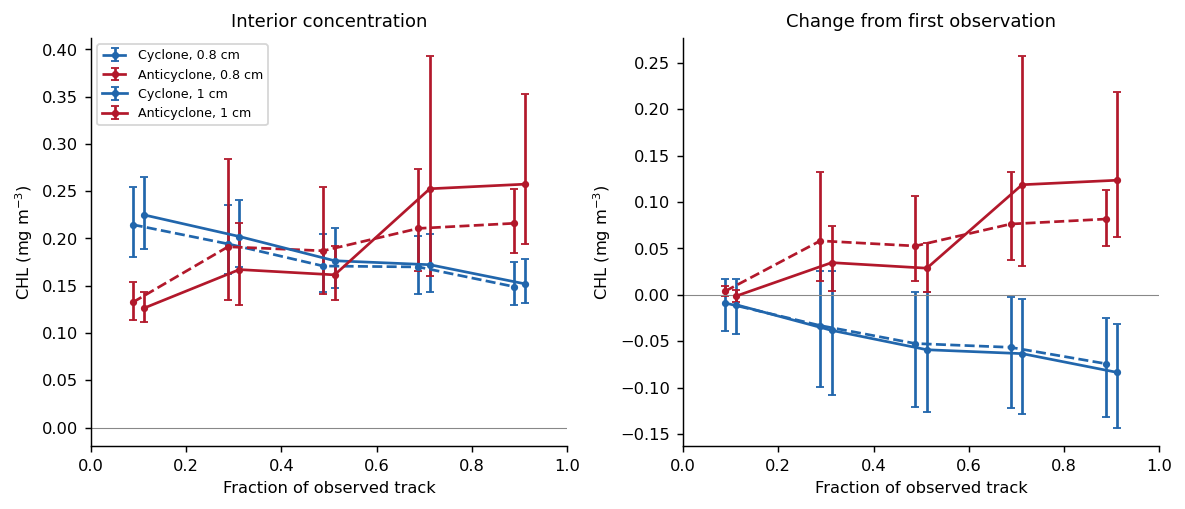

,polarity,field,age_bin,mean_baseline,mean_variant,ci_low_baseline,ci_high_baseline,ci_low_variant,ci_high_variant,intervals_overlap
19,cyclone,DIATO,4,-0.02106,-0.02464,-0.05201,0.00245,-0.05544,-0.00140,True
38,cyclone,GREEN,3,-0.01571,-0.01773,-0.03650,0.00023,-0.03784,-0.00099,True
77,cyclone,MICRO,2,-0.02821,-0.02984,-0.06400,-0.00039,-0.06629,0.00154,True
79,cyclone,MICRO,4,-0.03310,-0.03862,-0.07600,0.00068,-0.08278,-0.00520,True
117,anticyclone,DIATO,2,0.02612,0.02416,0.00032,0.06712,-0.00386,0.06959,True
128,anticyclone,DINO,3,0.00772,0.01917,0.00129,0.01433,-0.00006,0.05331,True
137,anticyclone,GREEN,2,0.01176,0.00570,0.00257,0.02474,-0.00119,0.01267,True
147,anticyclone,HAPTO,2,0.01063,0.00734,0.00345,0.01890,-0.00119,0.01567,True
159,anticyclone,PROCHLO,4,0.01732,0.01640,-0.00497,0.03838,0.00119,0.03170,True
177,anticyclone,MICRO,2,0.03207,0.02867,0.00163,0.08025,-0.00443,0.08103,True


In [8]:
point_comparison, heatmap_comparison = compare_summaries(point_summary, heatmap_summary)
point_comparison.to_parquet(SCRATCH / 'point_comparison.parquet', index=False)
heatmap_comparison.to_parquet(SCRATCH / 'heatmap_comparison.parquet', index=False)
late_chl = point_summary.loc[point_summary['field'].eq('CHL') & point_summary['metric'].eq('change') & point_summary['age_bin'].eq(N_AGE_BINS - 1)]
display(late_chl.set_index(['scenario', 'polarity'])[['mean', 'ci_low', 'ci_high', 'n_eddies']].reindex(PARAMETERS, level='scenario').round(4))
plot_point_comparison(point_summary, 'CHL')
changed_intervals = point_comparison.loc[point_comparison['metric'].eq('change') & point_comparison['interval_status_changed']]
display(changed_intervals[['polarity', 'field', 'age_bin', 'mean_baseline', 'mean_variant', 'ci_low_baseline', 'ci_high_baseline', 'ci_low_variant', 'ci_high_variant', 'intervals_overlap']].round(5))

,polarity,field,age_bin,interval_status_changed_2000,interval_status_changed_10000
3,cyclone,CHL,3,False,True
9,cyclone,DIATO,4,True,True
13,cyclone,DINO,3,False,True
18,cyclone,GREEN,3,True,True
29,cyclone,PROCHLO,4,False,True
37,cyclone,MICRO,2,True,True
39,cyclone,MICRO,4,True,False
48,cyclone,PICO,3,False,True
57,anticyclone,DIATO,2,True,True
63,anticyclone,DINO,3,True,True


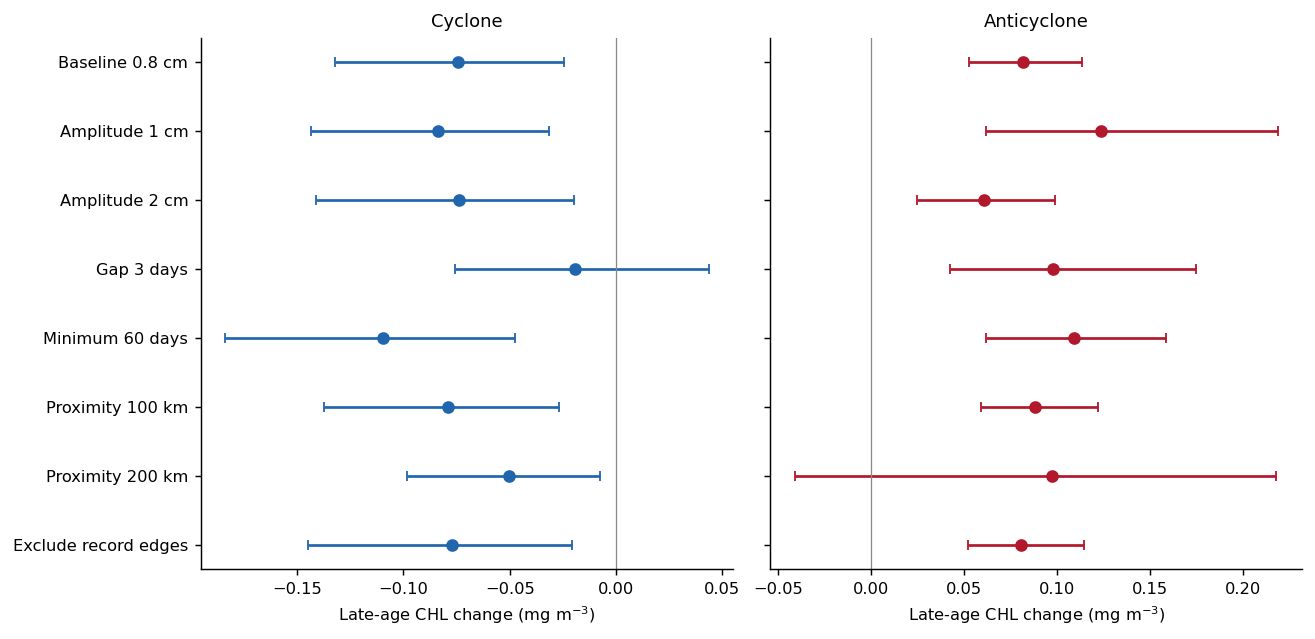

In [9]:
bootstrap_check, _ = summarize_interior(interior.loc[interior['scenario'].isin(['Baseline 0.8 cm', 'Amplitude 1 cm'])], n_bootstrap=10000)
bootstrap_check.to_parquet(SCRATCH / 'point_summary_10000.parquet', index=False)
check_points, _ = compare_summaries(bootstrap_check, heatmap_summary)
status_check = point_comparison.loc[point_comparison['metric'].eq('change'), ['polarity', 'field', 'age_bin', 'interval_status_changed']].merge(check_points.loc[check_points['metric'].eq('change'), ['polarity', 'field', 'age_bin', 'interval_status_changed']], on=['polarity', 'field', 'age_bin'], suffixes=('_2000', '_10000'), validate='one_to_one')
display(status_check.loc[status_check['interval_status_changed_2000'] | status_check['interval_status_changed_10000']])
fig, axes = cast(tuple[Figure, np.ndarray], plt.subplots(1, 2, figsize=(10, 4.8), layout='constrained', sharey=True))
for panel, polarity in enumerate(polarity_names):
    ax = cast(Axes, axes[panel])
    rows = late_chl.loc[late_chl['polarity'].eq(polarity)].set_index('scenario').reindex(PARAMETERS)
    y = np.arange(len(rows))
    ax.errorbar(rows['mean'].to_numpy(), y, xerr=np.vstack([rows['mean'] - rows['ci_low'], rows['ci_high'] - rows['mean']]), fmt='o', capsize=3, color='#2166ac' if polarity == 'cyclone' else '#b2182b')
    ax.axvline(0, color='#888888', linewidth=0.7)
    ax.yaxis.set_ticks(y)
    ax.yaxis.set_ticklabels(list(rows.index))
    ax.set(title=polarity.capitalize(), xlabel='Late-age CHL change (mg m$^{-3}$)')
cast(Axes, axes[0]).invert_yaxis()
fig.savefig(SCRATCH / 'parameter_comparison.png', dpi=170)
plt.show()

## Heatmaps and radial gradients
Baseline and 1 cm maps share the same concentration scale. Difference panels use a symmetric scale centered on zero. A core-minus-outer contrast compares the mean of the innermost two rings (0–0.4 speed radii) with the mean of the five outer rings (1–2 speed radii), within each eddy and age bin, before bootstrapping eddies. This provides a direct check of radial contrast instead of judging the color scale alone.

,polarity,field,cell_correlation,max_absolute_change,baseline_range,changed_display_mask_cells
0,anticyclone,CHL,0.8940,0.0653,0.1493,0
1,anticyclone,DIATO,0.5020,0.2919,0.0776,0
2,anticyclone,DINO,0.7709,0.0327,0.0327,0
3,anticyclone,GREEN,0.9325,0.0141,0.0365,0
4,anticyclone,HAPTO,0.9100,0.0293,0.0415,0
5,anticyclone,MICRO,0.5643,0.3246,0.0954,0
6,anticyclone,NANO,0.9100,0.0293,0.0415,0
7,anticyclone,PICO,0.9169,0.0125,0.0316,0
8,anticyclone,PROCHLO,0.8340,0.0187,0.0529,0
9,anticyclone,PROKAR,0.9649,0.0016,0.0058,0


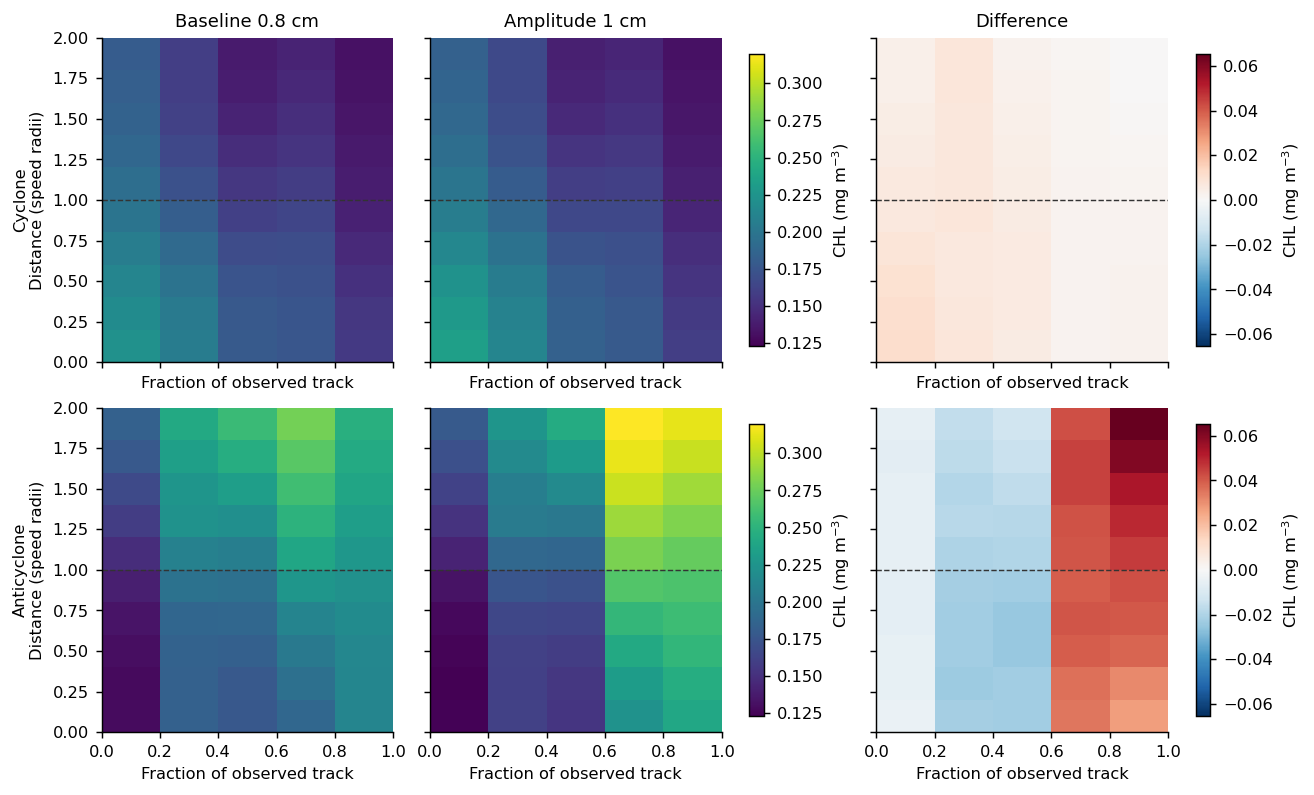

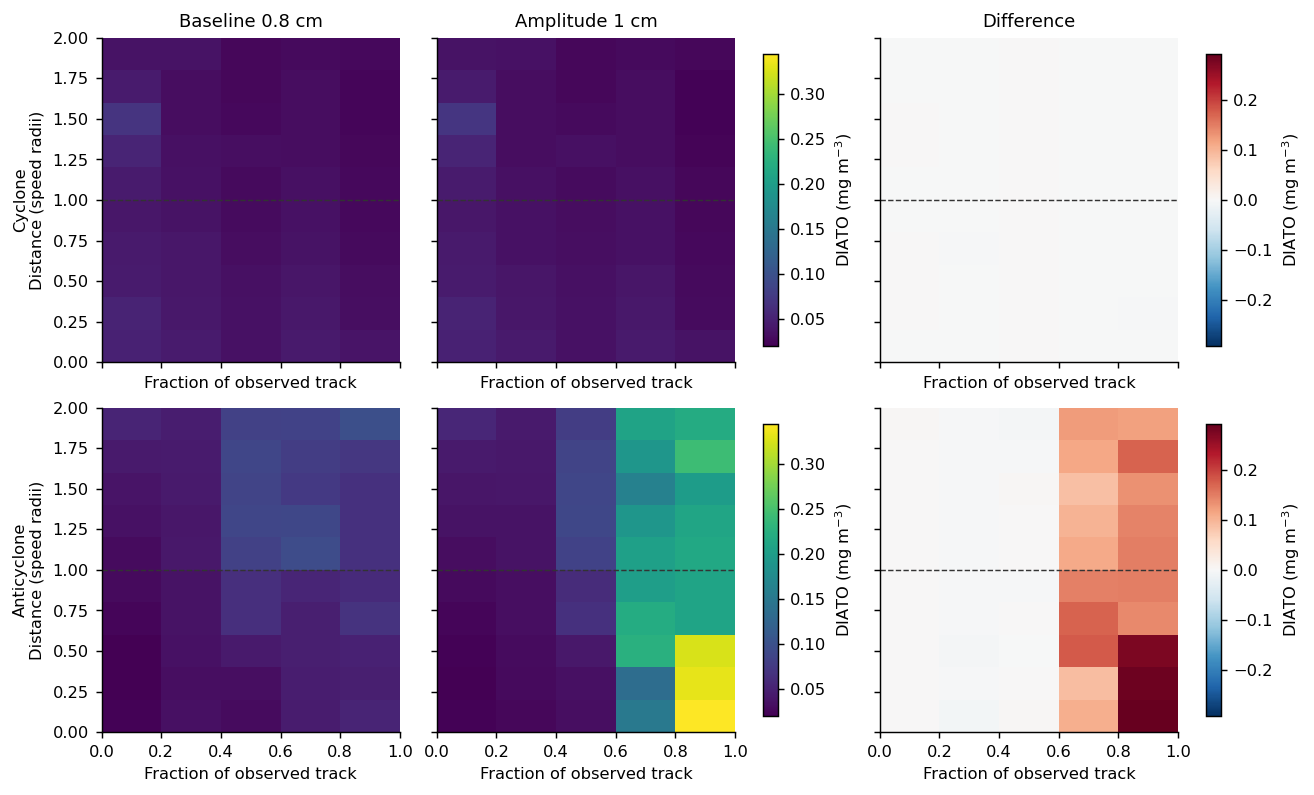

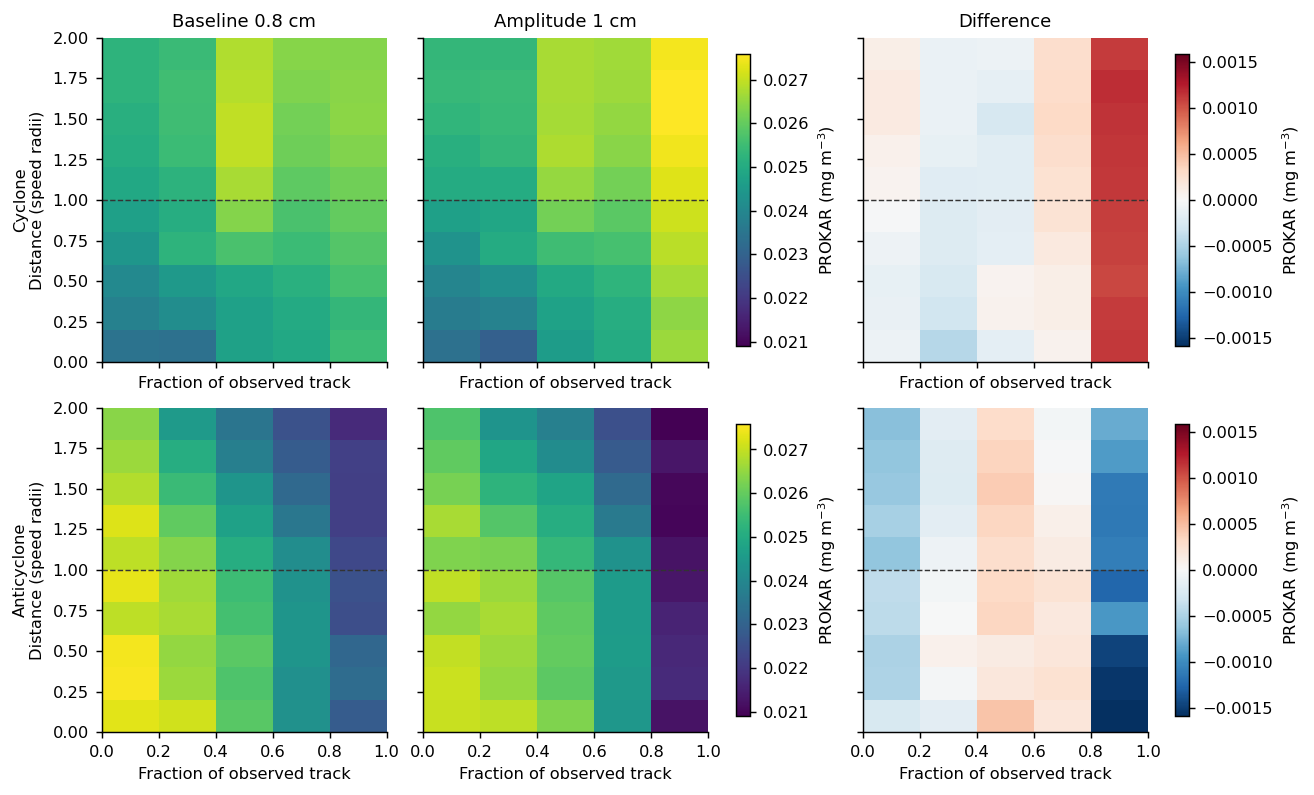

,scenario,polarity,field,age_bin,mean,ci_low,ci_high,n_eddies,excludes_zero
0,Amplitude 1 cm,anticyclone,CHL,0,-0.03770,-0.07939,-0.01374,37,True
200,Baseline 0.8 cm,anticyclone,CHL,0,-0.03885,-0.07810,-0.01577,41,True
40,Amplitude 1 cm,anticyclone,CHL,1,-0.04770,-0.08267,-0.01934,37,True
240,Baseline 0.8 cm,anticyclone,CHL,1,-0.04295,-0.07173,-0.01613,41,True
1,Amplitude 1 cm,anticyclone,CHL,2,-0.06191,-0.09842,-0.03589,37,True
201,Baseline 0.8 cm,anticyclone,CHL,2,-0.05547,-0.08801,-0.03151,42,True
2,Amplitude 1 cm,anticyclone,CHL,3,-0.07461,-0.10672,-0.04666,38,True
202,Baseline 0.8 cm,anticyclone,CHL,3,-0.06741,-0.09727,-0.04276,42,True
3,Amplitude 1 cm,anticyclone,CHL,4,-0.04985,-0.08553,-0.02232,38,True
203,Baseline 0.8 cm,anticyclone,CHL,4,-0.02454,-0.04271,-0.00744,42,True


In [10]:
radial_contrasts = summarize_radial_contrasts(eddy_cells)
radial_contrasts.to_parquet(SCRATCH / 'radial_contrasts.parquet', index=False)
heatmap_metrics = []
for key, values in heatmap_comparison.groupby(['polarity', 'field']):
    key = cast(tuple[str, str], key)
    heatmap_metrics.append({'polarity': key[0], 'field': key[1], 'cell_correlation': cast(pd.Series, values['mean_baseline']).corr(cast(pd.Series, values['mean_variant'])), 'max_absolute_change': values['difference'].abs().max(), 'baseline_range': values['mean_baseline'].max() - values['mean_baseline'].min(), 'changed_display_mask_cells': int(values['mean_baseline'].isna().ne(values['mean_variant'].isna()).sum())})
display(pd.DataFrame(heatmap_metrics).round(4))
for field in HEATMAP_FIELDS:
    plot_heatmap_comparison(heatmap_summary, field)
display(radial_contrasts.loc[radial_contrasts['scenario'].isin(['Baseline 0.8 cm', 'Amplitude 1 cm']) & radial_contrasts['field'].eq('CHL')].sort_values(['polarity', 'age_bin', 'scenario']).round(5))

## Which target eddies changed?
The correspondence table retains every shared-contour link, including splits and mergers. A track can have more than one counterpart. “No target counterpart” means none of its shared detections belonged to a target track in the other run; it does not necessarily mean that all detections disappeared.

In [11]:
track_matches = compare_tracks(movements)
track_matches.to_parquet(SCRATCH / 'track_matches.parquet', index=False)
target_changes = []
for polarity in polarity_names:
    old_ids = set(movements.loc[movements['scenario'].eq('Baseline 0.8 cm') & movements['polarity'].eq(polarity) & movements['is_target'], 'track_id'])
    new_ids = set(movements.loc[movements['scenario'].eq('Amplitude 1 cm') & movements['polarity'].eq(polarity) & movements['is_target'], 'track_id'])
    links = track_matches.loc[track_matches['polarity'].eq(polarity) & track_matches['is_target_baseline'] & track_matches['is_target_variant']]
    identical = links['shared_detections'].eq(links['baseline_detections']) & links['shared_detections'].eq(links['variant_detections']) & links['birth_shift_days'].eq(0) & links['death_shift_days'].eq(0)
    target_changes.append({'polarity': polarity, 'baseline_targets': len(old_ids), 'new_targets': len(new_ids), 'identical_detection_sequences': int(identical.sum()), 'baseline_ids_without_target_counterpart': sorted(old_ids - set(links['track_id_baseline'])), 'new_ids_without_target_counterpart': sorted(new_ids - set(links['track_id_variant']))})
display(pd.DataFrame(target_changes))
changed_links = track_matches.loc[(track_matches['is_target_baseline'] | track_matches['is_target_variant']) & (track_matches['birth_shift_days'].ne(0) | track_matches['death_shift_days'].ne(0) | track_matches['is_target_baseline'].ne(track_matches['is_target_variant']))]
display(changed_links[['polarity', 'track_id_baseline', 'track_id_variant', 'shared_detections', 'baseline_detections', 'variant_detections', 'movement_baseline', 'movement_variant', 'is_target_baseline', 'is_target_variant', 'birth_shift_days', 'death_shift_days']])

,polarity,baseline_targets,new_targets,identical_detection_sequences,baseline_ids_without_target_counterpart,new_ids_without_target_counterpart
0,cyclone,25,24,18,"[124, 353]",[286]
1,anticyclone,42,38,17,"[90, 97, 102, 106, 214, 220, 241, 337, 388]","[24, 65, 113, 309, 312]"


,polarity,track_id_baseline,track_id_variant,shared_detections,baseline_detections,variant_detections,movement_baseline,movement_variant,is_target_baseline,is_target_variant,birth_shift_days,death_shift_days
24,anticyclone,22,24,80,90,183,SS,SN,False,True,0,100
36,anticyclone,34,34,39,59,39,NN,NN,True,True,0,-23
65,anticyclone,64,24,101,158,183,SS,SN,False,True,-89,-70
67,anticyclone,64,113,38,158,60,SS,SN,False,True,141,26
70,anticyclone,67,65,71,257,71,SS,SN,False,True,2,-202
98,anticyclone,90,76,34,37,58,SN,NN,True,False,-30,-1
108,anticyclone,97,93,33,35,43,SN,SS,True,False,0,6
113,anticyclone,102,104,36,47,50,SN,SS,True,False,12,17
119,anticyclone,106,98,93,95,102,SN,NN,True,False,-10,0
149,anticyclone,133,156,68,134,74,SN,SN,True,True,59,-4


## Influence of individual anticyclones
This leave-one-eddy-out calculation is a diagnostic, not a new exclusion rule. It ranks the anticyclones by their influence on the 1 cm late-age CHL change. The leading track in the executed run was 309. It combined detections from baseline tracks 316 and 317, which were not targets, and its first detection lay 126.5 km from the axis. Its March composites contained high CHL and diatom estimates. The diatom estimates exceeded CHL in those composites; their biological interpretation needs a separate product-quality check.

The same track drove the strong late-age diatom hotspot. Removing it for this diagnostic reduced the 1 cm CHL change estimate to about 0.086 mg/m³ and the most affected diatom cell from about 0.332 to 0.056 mg/m³. The track remains included in the reported 1 cm results.

In [12]:
late_eddies = eddy_bins.loc[eddy_bins['scenario'].eq('Amplitude 1 cm') & eddy_bins['polarity'].eq('anticyclone') & eddy_bins['field'].eq('CHL') & eddy_bins['age_bin'].eq(N_AGE_BINS - 1)].copy()
late_eddies['mean_without_eddy'] = (late_eddies['change'].sum() - late_eddies['change']) / (late_eddies['change'].count() - 1)
late_eddies['influence'] = late_eddies['change'].mean() - late_eddies['mean_without_eddy']
influence = late_eddies.sort_values('influence', ascending=False)
display(influence[['track_id', 'change', 'mean_without_eddy', 'influence']].head(8).round(5))
influential_id = int(influence.iloc[0]['track_id'])
display(track_matches.loc[track_matches['polarity'].eq('anticyclone') & track_matches['track_id_variant'].eq(influential_id)])
display(interior.loc[interior['scenario'].eq('Amplitude 1 cm') & interior['polarity'].eq('anticyclone') & interior['track_id'].eq(influential_id), ['track_id', 'date', 'age_frac', 'center_lon', 'center_lat', 'CHL', 'DIATO']].round(5))
diatom_cells = eddy_cells.loc[eddy_cells['scenario'].eq('Amplitude 1 cm') & eddy_cells['polarity'].eq('anticyclone') & eddy_cells['field'].eq('DIATO') & eddy_cells['age_bin'].eq(N_AGE_BINS - 1)]
with_eddy = diatom_cells.groupby('radial_bin')['value'].mean()
without_eddy = diatom_cells.loc[diatom_cells['track_id'].ne(influential_id)].groupby('radial_bin')['value'].mean()
display(pd.DataFrame({'all_target_eddies': with_eddy, 'without_influential_eddy': without_eddy}).round(5))

,track_id,change,mean_without_eddy,influence
1243,309,1.52711,0.08556,0.03794
1144,267,0.36695,0.11692,0.00658
3,1,0.31272,0.11839,0.00511
1194,285,0.30475,0.11860,0.00490
1474,348,0.19698,0.12151,0.00199
544,156,0.19563,0.12155,0.00195
1284,312,0.17405,0.12213,0.00137
1094,261,0.16819,0.12229,0.00121


,polarity,track_id_baseline,track_id_variant,shared_detections,baseline_detections,variant_detections,baseline_fraction,variant_fraction,birth_date_baseline,death_date_baseline,movement_baseline,is_target_baseline,birth_date_variant,death_date_variant,movement_variant,is_target_variant,birth_shift_days,death_shift_days
328,anticyclone,316,309,12,95,23,0.126316,0.521739,2025-02-15,2025-06-03,NN,False,2025-02-24,2025-03-29,NN,True,9,-66
332,anticyclone,317,309,10,35,23,0.285714,0.434783,2025-02-15,2025-03-29,NN,False,2025-02-24,2025-03-29,NN,True,9,0


,track_id,date,age_frac,center_lon,center_lat,CHL,DIATO
3949,309,2025-02-21,0.00000,-56.55472,41.89185,0.17266,0.07797
4008,309,2025-03-01,0.15152,-56.90958,42.03809,0.25768,0.08046
4067,309,2025-03-09,0.39394,-58.21106,42.19856,0.71918,0.18311
4120,309,2025-03-17,0.63636,-59.02472,42.46396,2.26192,6.22590
4173,309,2025-03-25,0.87879,-61.36887,43.59126,1.69977,6.03960


,all_target_eddies,without_influential_eddy
radial_bin,,
0,0.34430,0.05803
1,0.33247,0.05577
2,0.32401,0.05772
3,0.20867,0.07047
4,0.20936,0.06609
5,0.21467,0.07246
6,0.21093,0.07223
7,0.19757,0.06958
8,0.24241,0.07051


## Interpretation and verification
The broad CHL result was stable to the 1 cm cutoff: cyclones lost CHL, anticyclones gained CHL, and their radial contrasts retained their signs with intervals excluding zero. The anticyclone effect size and some group-level age and radial patterns were sensitive to track association and target membership. The 1 cm result therefore did not meet the condition of a negligible change, and the main run remained at 0.8 cm.

Other parameters also mattered. With a three-day gap allowance, the late-age cyclone CHL interval included zero. With a 200 km proximity threshold, the anticyclone interval included zero. These results describe sensitivity of the current cohort and method; they do not identify a universally correct cutoff.

Verification covered exact regeneration of the saved baseline daily detections, exact reproduction of baseline endpoint classifications, and exact reproduction of baseline target concentrations and ages. The baseline CHL and group heatmaps were also independently compared with execution of the existing research notebooks. Tables and figures use reconstructed tracks and new collocations, with no synthetic observations. The Gulf Stream axis algorithm and the biological coverage thresholds were held fixed.

In [13]:
checks = {
    'baseline_daily_files_verified': int(detection_summary['amplitude_cm'].eq(0.8).sum()),
    'baseline_target_composites_verified': len(baseline),
    'unique_scenario_eddy_composite_keys': not interior.duplicated(['scenario', *identity_columns, 'date']).any(),
    'all_requested_scenarios_present': set(PARAMETERS) == set(interior['scenario']),
    'baseline_and_1cm_late_CHL_intervals_exclude_zero': bool(late_chl.loc[late_chl['scenario'].isin(['Baseline 0.8 cm', 'Amplitude 1 cm']), 'excludes_zero'].all()),
}
display(pd.Series(checks, name='verification'))
(SCRATCH / 'completed.json').write_text(json.dumps(signature, indent=2))
print(f'Experimental tables, tracks, and figures: {SCRATCH}')

Experimental tables, tracks, and figures: /tmp/codex-eddy-sensitivity.7q0BVW


baseline_daily_files_verified                       2020
baseline_target_composites_verified                  783
unique_scenario_eddy_composite_keys                 True
all_requested_scenarios_present                     True
baseline_and_1cm_late_CHL_intervals_exclude_zero    True
Name: verification, dtype: object